**GLAB09 • by~ADALID**
>Adalid Portillo Choque<br>
>INF672 - Machine Learning<br>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update(
    {
        'figure.figsize':(7, 4.2),
        'axes.grid': True, 
        'grid.alpha': 0.3,
        'axes.spines.top': False,
        'axes.spines.right':False 
    }
)

In [3]:
rng = np.random.default_rng(42)
m = 60

horas = rng.uniform(0,10, m)
nota = 30 + 5*horas + rng.normal(0, 5, m)

for h, n in zip(horas[:5], nota[:5]):
    print(f'horas {h:5.2f}   nota = {n:6.2f}')

horas  7.74   nota =  64.37
horas  4.39   nota =  56.79
horas  8.59   nota =  64.52
horas  6.97   nota =  63.19
horas  0.94   nota =  35.52


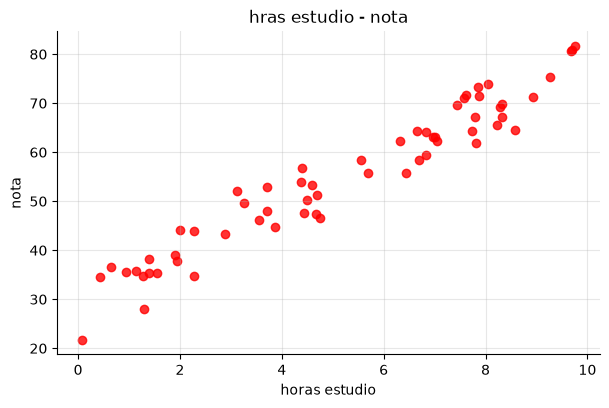

In [4]:
plt.scatter(horas, nota, color = '#f00', alpha=0.8)
plt.xlabel('horas estudio')
plt.ylabel('nota')
plt.title('hras estudio - nota')
plt.show()

&nbsp; ***<--------PARTE A-------->***

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score)

x = horas.reshape(-1, 1)
y = nota


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)
print('train = ', x_train.shape, ' test = ', x_test.shape)

train =  (48, 1)  test =  (12, 1)


estamos usando 80 20, con esos 20 que seria 12, haremos el test. para ver como aprendio

In [6]:
modelo = LinearRegression()
modelo.fit(x_train, y_train)

weight = modelo.coef_[0]
bias = modelo.intercept_

print(f'pendiente {weight} --- 5')
print(f'intercepto {bias} --- 30')
print(f'modelo aprendio: nota = {bias:.2f} + {weight:.2f} * horas')

pendiente 5.0674504490797645 --- 5
intercepto 28.539417759276674 --- 30
modelo aprendio: nota = 28.54 + 5.07 * horas


In [7]:
y_pred = modelo.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print('MAE : ', mae) #E absoluto
print('MSE : ', mse) #E cuadratico medio
print('RMSE : ', np.sqrt(mse)) #raiz cuadrada de E cuadratico medio
print('R^2 : ', r2_score(y_test, y_pred)) #coef de determinacion


MAE :  2.781036107268672
MSE :  12.187554585107028
RMSE :  3.4910678287748906
R^2 :  0.9460732558288573


---

&nbsp; ***<--------PARTE B-------->***

In [8]:
nuevos = np.array([[2], [5], [8]])
for h, p in zip(nuevos.ravel(), modelo.predict(nuevos)):
    print(f'{h} se predice de {p}')

2 se predice de 38.6743186574362
5 se predice de 53.876670004675496
8 se predice de 69.07902135191479


modelo aprendio: nota = 28.54 + 5.07 * horas <br>
--> [2] : 28.54 + 5.07*2 = 28.54 + 10.14 = 38.68 <br>
--> [8] : 28.54 + 5.07*8 = 28.54 + 40.56 = 69.10 <br>

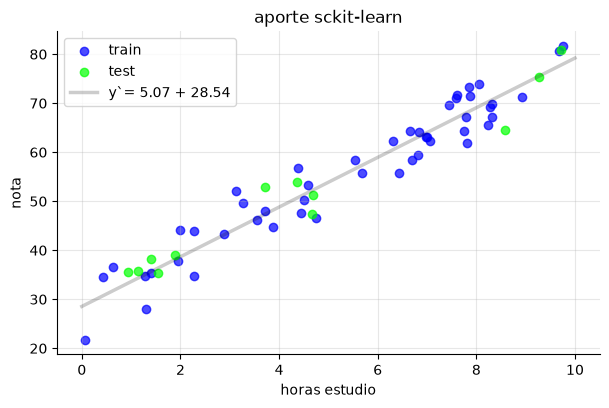

In [9]:
xs = np.linspace(0,10, 100).reshape(-1, 1)
plt.scatter(x_train, y_train, color='#00f', alpha=0.7, label='train')
plt.scatter(x_test, y_test, color='#0f0', alpha=0.7, label='test')
plt.plot(xs, modelo.predict(xs), color='#000', alpha=0.2, label=f'y`= {weight:.2f} + {bias:.2f}', lw=2.5)
plt.xlabel('horas estudio')
plt.ylabel('nota')
plt.title('aporte sckit-learn')
plt.legend()
plt.show()

In [10]:
def costo (w, b, x, y):
    """J(w,b) = (1/2m) sum(w*x+b-y)^2"""
    y_pred =w*x+b
    return np.mean((y_pred-y)**2)/2

x_train, x_test = x_train.ravel(), x_test.ravel()
print(f'J(0, 0)  = {costo(0, 0, x_train, y_train):8.2f}  < recta en 0')
print(f'J(5, 30) = {costo(5, 30, x_train, y_train):8.2f}  <- relación real')

J(0, 0)  =  1667.25  < recta en 0
J(5, 30) =     7.88  <- relación real


In [11]:
def gradientes(w, b, x, y):
    """Devuelve (∂J/∂w, ∂J/∂b)."""
    error = (w * x + b) - y
    dw = np.mean(error * x)
    db = np.mean(error)
    return dw, db

dw, db = gradientes(0, 0, x_train, y_train)
print(f'En (w, b) = (0, 0):  ∂J/∂w = {dw:.2f},  ∂J/∂b = {db:.2f}')

En (w, b) = (0, 0):  ∂J/∂w = -339.86,  ∂J/∂b = -55.98


In [12]:
def descenso_gradiente(x, y, alpha=0.01, iteraciones=10_000):
    
    w, b = 0.0, 0.0     # punto de partida
    historial = []      # J de cada iteración
    for i in range(iteraciones):
        dw, db = gradientes(w, b, x, y)     # 1) calcular el gradiente
        w = w - alpha * dw                  # 2) dar un paso cuesta abajo
        b = b - alpha * db
        historial.append(costo(w, b, x, y)) # 3) registrar el costo
        if i in (0, 10, 100, 1000, iteraciones - 1):
            print(f'iter {i:>5}:  w = {w:7.4f}   b = {b:8.4f}'
                  f'   J = {historial[-1]:9.4f}')
    return w, b, historial
w_gd, b_gd, historial = descenso_gradiente(x_train, y_train, alpha=0.01, iteraciones=10_000)

iter     0:  w =  3.3986   b =   0.5598   J =  702.4903
iter    10:  w =  8.9765   b =   1.9226   J =   77.3678
iter   100:  w =  8.3954   b =   6.1889   J =   56.6861
iter  1000:  w =  5.6493   b =  24.6320   J =    8.7716
iter  9999:  w =  5.0675   b =  28.5394   J =    7.2610


Text(0.5, 1.0, 'curva de aprendizaje')

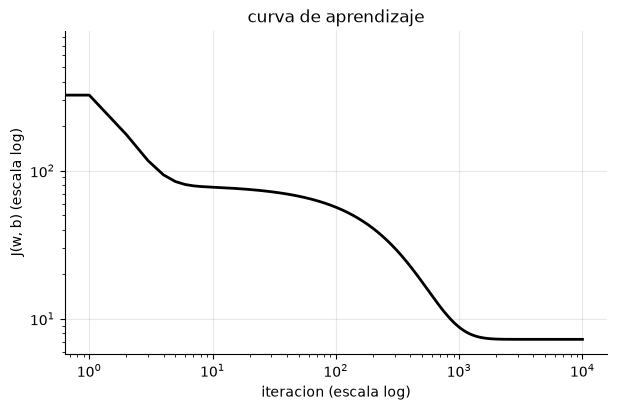

In [13]:
plt.plot(historial, color='#000', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('iteracion (escala log)')
plt.ylabel('J(w, b) (escala log)')
plt.title('curva de aprendizaje')
#plt.show() #--> ya trae por defecto, no es necesario en entornos como jupyter o colab 

In [14]:
print(f'{"":22}{"w":>10}{"b":>10}')
print(f'{"Valor real":22}{5:>10.4f}{30:>10.4f}')
print(f'{"scikit-learn":22}{weight:>10.4f}{bias:>10.4f}')
print(f'{"Descenso de gradiente":22}{w_gd:>10.4f}{b_gd:>10.4f}')
print(f'\nDiferencia |w_sk − w_gd| = {abs(w_gd - weight):.2e}')
print(f'Diferencia |b_sk − b_gd| = {abs(bias - b_gd):.2e}')

                               w         b
Valor real                5.0000   30.0000
scikit-learn              5.0675   28.5394
Descenso de gradiente     5.0675   28.5394

Diferencia |w_sk − w_gd| = 1.55e-08
Diferencia |b_sk − b_gd| = 1.04e-07


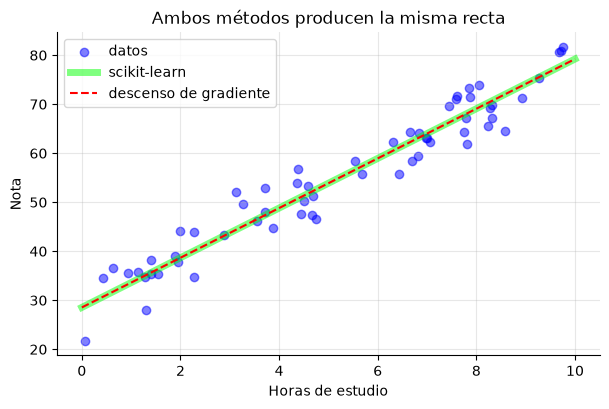

In [15]:
plt.scatter(horas, nota, color='#00f', alpha=0.5, label='datos')
plt.plot(xs, modelo.predict(xs), color='#0f0', lw=5, alpha=0.5, label='scikit-learn')
plt.plot(xs, w_gd * xs + b_gd, color='#f00', lw=1.5, ls='--', label='descenso de gradiente')
plt.xlabel('Horas de estudio'); plt.ylabel('Nota')
plt.title('Ambos métodos producen la misma recta'); plt.legend()